# Sentiment Analysis of Financial News Headlines
## This task tests your ability to apply NLP techniques you've learnt to classify a news headline containing financial information into either one of the sentiments (Positive, Negative or Neutral)

### Dataset:
https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv

## Max Marks without Bonus attempted: 80 points
## Max Marks with Bonus: 100 points
- ### Bonus: 20 points

### Steps
- 1. Download the dataset
- 2. Load the dataset
- 3. Explore the dataset (Exploratory Data Analysis)
- 4. Clean the data
- 5. Apply SMOTE for imbalanced data [Optional] --> Carries Bonus Marks
- 6. Build a BoW model
- 7. Build a Tf-Idf model
- 8. Split train and test data
- 9. Use one ML Classifying algorithm to classify the finanical news headline data
- 10. Use another ML classifying algorithm to classify them
- 11. Plot Confusion matrix

## 1. Download the dataset [1 point]

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv"
data = pd.read_csv(url, encoding='ISO-8859-1')

# Display dataset preview
print(data.head())
print(data.info())

    neutral  \
0   neutral   
1  negative   
2  positive   
3  positive   
4  positive   

  According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .  
0  Technopolis plans to develop in stages an area...                                                                               
1  The international electronic industry company ...                                                                               
2  With the new production plant the company woul...                                                                               
3  According to the company 's updated strategy f...                                                                               
4  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...                                                                               
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column

## 2. Load the dataset [1 point]

In [5]:
# Check for null values and basic info
print(data.info())
print(data.isnull().sum())


# Rename columns
data.columns = ['sentiment', 'headline']

# Preview the fixed dataset
print(data.head())
print(data.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                           --------------  ----- 
 0   neutral                                                                                                                          4845 non-null   object
 1   According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .  4845 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB
None
neutral                                                                                                                            0
According to Gran , the company has no plans to move all production to Russia , althoug

## 3. Explore the dataset [10 points]

sentiment
neutral     2878
positive    1363
negative     604
Name: count, dtype: int64


<ipython-input-6-0c38f48e6913>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis')


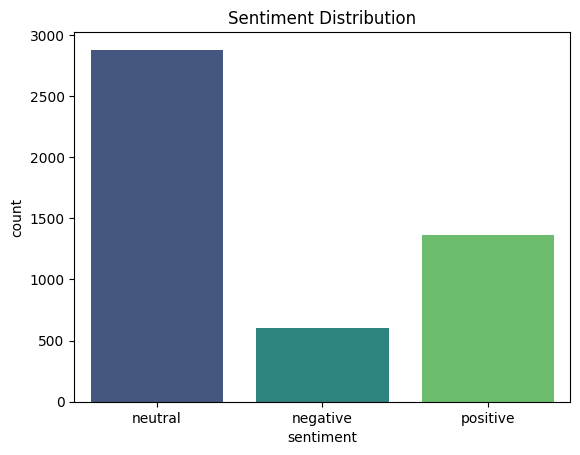

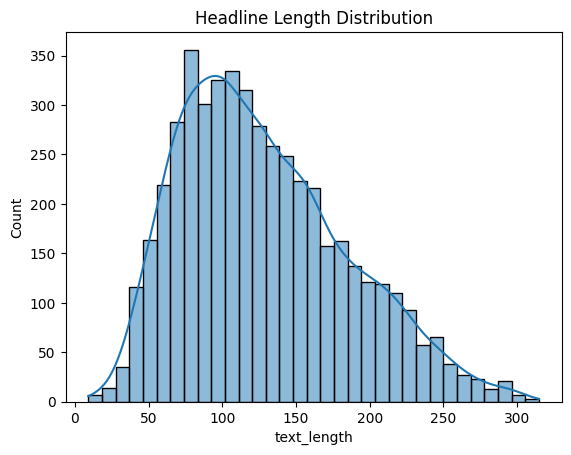

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment distribution
print(data['sentiment'].value_counts())

# Visualize sentiment distribution
sns.countplot(x='sentiment', data=data, palette='viridis')
plt.title("Sentiment Distribution")
plt.show()

# Check text lengths
data['text_length'] = data['headline'].apply(len)
sns.histplot(data['text_length'], kde=True)
plt.title("Headline Length Distribution")
plt.show()


## 4. Clean the data [5 points]

In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower()  # Convert to lowercase
    tokens = word_tokenize(text)  # Tokenize
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize
    return ' '.join(tokens)

# Apply preprocessing
data['cleaned_headline'] = data['headline'].apply(clean_text)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 5. SMOTE (Imbalanced dataset) [OPTIONAL] BONUS [20 points]
Hint: Use **imblearn** library

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Prepare data for SMOTE
X = data['cleaned_headline']
y = data['sentiment']

# Convert text to numerical representation using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)


## 6. BoW model [15 points]

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(data['cleaned_headline'])

# Split data
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)


## 7. Tf-idf model [15 points]

In [11]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


## 8. Split train test data [3 points]

In [15]:
from sklearn.model_selection import train_test_split

# Splitting features and labels
X = data['headline']  # Features (news headlines)
y = data['sentiment']  # Labels (sentiments)

# Splitting into train and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split sizes
print(f"Training data size: {X_train.shape[0]}")
print(f"Test data size: {X_test.shape[0]}")


Training data size: 3876
Test data size: 969


## 9. Classification Algorithm [10 points]
- Train
- Predict

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_bow, y_train)

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_bow)
print("Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression - Classification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression - Accuracy: 0.7285861713106295
Logistic Regression - Classification Report:
               precision    recall  f1-score   support

    negative       0.67      0.46      0.55       115
     neutral       0.75      0.87      0.81       567
    positive       0.69      0.55      0.61       287

    accuracy                           0.73       969
   macro avg       0.70      0.63      0.65       969
weighted avg       0.72      0.73      0.72       969



## 10. Another Classification Algorithm [10 points]
- Train
- Predict

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_tfidf)
print("Random Forest - Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest - Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest - Accuracy: 0.7275541795665634
Random Forest - Classification Report:
               precision    recall  f1-score   support

    negative       0.80      0.38      0.52       115
     neutral       0.72      0.94      0.82       567
    positive       0.74      0.44      0.55       287

    accuracy                           0.73       969
   macro avg       0.75      0.59      0.63       969
weighted avg       0.73      0.73      0.70       969



## 11. Confusion Matrixes for two classification algorithms and two feature extractor methods [10 points]

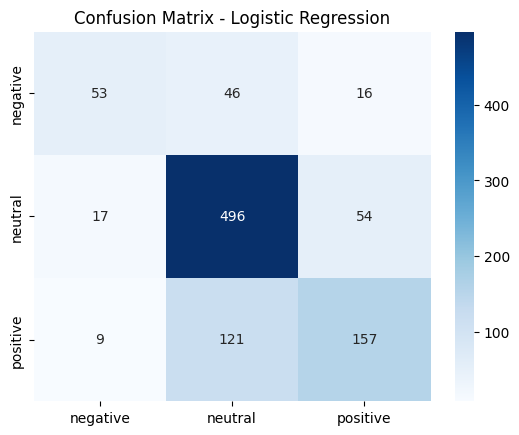

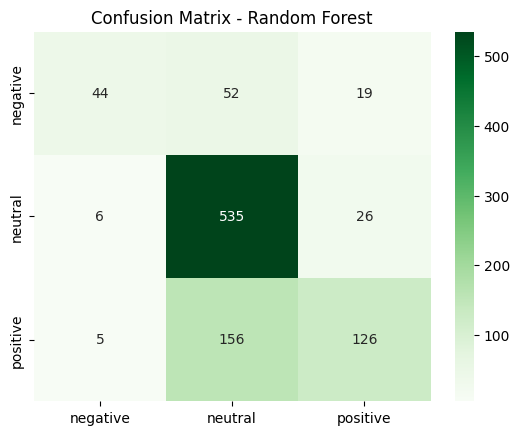

In [14]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.show()
